In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

project_root = os.path.dirname(os.path.abspath(''))
if project_root not in sys.path:
    sys.path.append(project_root)

# from FEATURES.features import *
from BACKTEST.backtestCalculateEVS import *
from BACKTEST.backtest import backtestPairs, calculatePairMetrics
# from MODELS.teamInfo import *


In [2]:
import joblib


# Load NGBoost mean and variance models
mean_model = joblib.load('../MODELS/SAVED_MODELS/NGBOOST_PTS_MEAN_MODEL_TEST.pkl')
variance_model = joblib.load('../MODELS/SAVED_MODELS/NGBOOST_PTS_VAR_MODEL_TEST.pkl')
calibration_factor = joblib.load('../MODELS/SAVED_MODELS/NGBOOST_PTS_CALIBRATION_FACTOR.pkl')

models = {
    'mean': mean_model,
    'variance': variance_model,
    'calibration_factor': calibration_factor
}

features = joblib.load('../MODELS/SAVED_MODELS/feature_list.pkl')

print(f"Loaded NGBoost models with calibration factor: {calibration_factor}")
print(f"Number of features: {len(features)}")

Loaded NGBoost models with calibration factor: 0.95
Number of features: 128


In [3]:
pd.set_option('display.max_columns', None)

s25_pts = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_25.csv')
s24_pts = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_24.csv')
for df in [s25_pts,s24_pts]:
    df['MIN_MAX_LAST_10'] = df.groupby('PLAYER_ID')['MIN'].shift(1).rolling(10).max().values
    df['MIN_MIN_LAST_10'] = df.groupby('PLAYER_ID')['MIN'].shift(1).rolling(10).min().values
    df['MIN_MAX_LAST_20'] = df.groupby('PLAYER_ID')['MIN'].shift(1).rolling(20).max().values
    df['MIN_MIN_LAST_20'] = df.groupby('PLAYER_ID')['MIN'].shift(1).rolling(20).min().values
    df['MIN_MAX_LAST_40'] = df.groupby('PLAYER_ID')['MIN'].shift(1).rolling(40).max().values
    df['MIN_MIN_LAST_40'] = df.groupby('PLAYER_ID')['MIN'].shift(1).rolling(40).min().values
df = pd.concat([s25_pts, s24_pts]).sort_values(by='GAME_DATE')
df.sample()

,Unnamed: 0,Unnamed: 0.2,PLAYER_NAME,PLAYER_ID,MATCHUP,TEAM_ABBREVIATION,TEAM_ID,OPP_ABBREVIATION,HOME_GAME,GAME_ID,GAME_DATE,WL,PTS,AST,REB,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,STL,BLK,TOV,PLUS_MINUS,FANTASY_PTS,POINT_PER_SHOT,EFG,START_POSITION,COMMENT,E_OFF_RATING,E_DEF_RATING,NET_RATING,OREB_PCT,DREB_PCT,REB_PCT,AST_PCT,EFG_PCT,AST_TOV,USG_PCT,TS_PCT,E_PACE,PACE,PIE,POSS,PACE_PER40,E_USG_PCT,MIN,SPD,DIST,ORBC,DRBC,RBC,TCHS,SAST,FTAST,PASS,CFGM,CFGA,CFG_PCT,UFGM,UFGA,UFG_PCT,DFGM,DFGA,DFG_PCT,PTS_OFF_TOV,PTS_2ND_CHANCE,PTS_FB,PTS_PAINT,OPP_PTS_OFF_TOV,OPP_PTS_2ND_CHANCE,OPP_PTS_FB,OPP_PTS_PAINT,BLKA,PF,PFD,IS_PLAYOFF,TEAM_SEASON_ID_x,whos_favored,spread,total,team_is_favored,team_spread,OPP_BLOWOUT_RISK,TEAM_NAME,TEAM_MIN,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_STL,TEAM_BLK,TEAM_TOV,TEAM_PF,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_PACE,GAME_PACE,OPP_PACE,OPP_TEAM_ID,TEAM_OFF_RATING,TEAM_DEF_RATING,OPP_DEF_RATING,OPP_OFF_RATING,OPP_PTS,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_REB,OPP_AST,OPP_STL,OPP_BLK,OPP_TOV,percentageFieldGoalsAttempted2pt,percentageFieldGoalsAttempted3pt,percentagePoints2pt,percentagePointsMidrange2pt,percentagePoints3pt,percentagePointsFastBreak,percentagePointsFreeThrow,percentagePointsOffTurnovers,percentagePointsPaint,percentageAssisted2pt,percentageUnassisted2pt,percentageAssisted3pt,percentageUnassisted3pt,percentageAssistedFGM,percentageUnassistedFGM,matchupFieldGoalsMade,matchupFieldGoalsAttempted,matchupThreePointersMade,matchupThreePointersAttempted,playerPoints,matchupMinutes,DEF_FG_PCT_ALLOWED,DEF_3PT_PCT_ALLOWED,PTS_ALLOWED_PER_MIN,AGE,FREQ_FG3,FG3M_main,FG3A_main,FG3_PCT_main,NS_FG3_PCT,PLUS_MINUS_FG3,FREQ_FG2,FG2M,FG2A,FG2_PCT,NS_FG2_PCT,PLUS_MINUS_FG2,FREQ_LT_06,FGM_LT_06,FGA_LT_06,LT_06_PCT,NS_LT_06_PCT,PLUS_MINUS_LT_06,FREQ_LT_10,FGM_LT_10,FGA_LT_10,LT_10_PCT,NS_LT_10_PCT,PLUS_MINUS_LT_10,FREQ_GT_15,FGM_GT_15,FGA_GT_15,GT_15_PCT,NS_GT_15_PCT,PLUS_MINUS_GT_15,DEF_TOV_FORCED_PER_MIN,DEF_BLOCKS_PER_MIN,DEF_SHOOTING_FOULS_PER_MIN,DEF_AST_ALLOWED_PER_MIN,STARTING,GAMES_THIS_SEASON,HEIGHT,WEIGHT,GUARD,FORWARD,CENTER,TEAM_DAYS_REST,PLAYER_DAYS_REST,TEAM_B2B,IS_BACK_TO_BACK,PLAYER_MISSED_LAST,PTS_ROLLING_AVG_5,AST_ROLLING_AVG_5,FGM_ROLLING_AVG_5,FGA_ROLLING_AVG_5,FG_PCT_ROLLING_AVG_5,FG3M_ROLLING_AVG_5,FG3A_ROLLING_AVG_5,FG3_PCT_ROLLING_AVG_5,FTA_ROLLING_AVG_5,FTM_ROLLING_AVG_5,FT_PCT_ROLLING_AVG_5,TOV_ROLLING_AVG_5,TS_PCT_ROLLING_AVG_5,USG_PCT_ROLLING_AVG_5,MIN_ROLLING_AVG_5,PACE_ROLLING_AVG_5,PIE_ROLLING_AVG_5,E_OFF_RATING_ROLLING_AVG_5,NET_RATING_ROLLING_AVG_5,TCHS_ROLLING_AVG_5,POSS_ROLLING_AVG_5,EFG_PCT_ROLLING_AVG_5,percentagePointsPaint_ROLLING_AVG_5,percentagePointsMidrange2pt_ROLLING_AVG_5,percentagePoints3pt_ROLLING_AVG_5,PTS_ROLLING_AVG_10,AST_ROLLING_AVG_10,FGM_ROLLING_AVG_10,FGA_ROLLING_AVG_10,FG_PCT_ROLLING_AVG_10,FG3M_ROLLING_AVG_10,FG3A_ROLLING_AVG_10,FG3_PCT_ROLLING_AVG_10,FTA_ROLLING_AVG_10,FTM_ROLLING_AVG_10,FT_PCT_ROLLING_AVG_10,TOV_ROLLING_AVG_10,TS_PCT_ROLLING_AVG_10,USG_PCT_ROLLING_AVG_10,MIN_ROLLING_AVG_10,PACE_ROLLING_AVG_10,PIE_ROLLING_AVG_10,E_OFF_RATING_ROLLING_AVG_10,NET_RATING_ROLLING_AVG_10,TCHS_ROLLING_AVG_10,POSS_ROLLING_AVG_10,EFG_PCT_ROLLING_AVG_10,percentagePointsPaint_ROLLING_AVG_10,percentagePointsMidrange2pt_ROLLING_AVG_10,percentagePoints3pt_ROLLING_AVG_10,PTS_ROLLING_AVG_40,AST_ROLLING_AVG_40,FGM_ROLLING_AVG_40,FGA_ROLLING_AVG_40,FG_PCT_ROLLING_AVG_40,FG3M_ROLLING_AVG_40,FG3A_ROLLING_AVG_40,FG3_PCT_ROLLING_AVG_40,FTA_ROLLING_AVG_40,FTM_ROLLING_AVG_40,FT_PCT_ROLLING_AVG_40,TOV_ROLLING_AVG_40,TS_PCT_ROLLING_AVG_40,USG_PCT_ROLLING_AVG_40,MIN_ROLLING_AVG_40,PACE_ROLLING_AVG_40,PIE_ROLLING_AVG_40,E_OFF_RATING_ROLLING_AVG_40,NET_RATING_ROLLING_AVG_40,TCHS_ROLLING_AVG_40,POSS_ROLLING_AVG_40,EFG_PCT_ROLLING_AVG_40,percentagePointsPaint_ROLLING_AVG_40,percentagePointsMidrange2pt_ROLLING_AVG_40,percentagePoints3pt_ROLLING_AVG_40,GAMES_VS_OPP,MATCHUP_AVG_PTS_TO_DATE,PTS

In [4]:
backtestData = pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/dfs_data.csv')
backtestData = backtestData[(backtestData['BOOKMAKER'] == 'underdog') &  (backtestData['CATEGORY'] == 'player_points')]
backtestData.sample(5)


/var/folders/nw/9w4r5hrd05s122kt5hg_t8bw0000gn/T/ipykernel_52074/1633982547.py:1: DtypeWarning: Columns (11,12,14) have mixed types. Specify dtype option on import or set low_memory=False.
  backtestData = pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/dfs_data.csv')


,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,NAME,CATEGORY,BOOKMAKER,SIDE,LINE,ODDS,HOME_TEAM,AWAY_TEAM,game_id,commence_time,GAME_DATE,period_id,fair_line,fair_odds,OVER/ODDS
181028,181028,181028,98219,Zach Edey,player_points,underdog,under,10.5,-137,Detroit Pistons,Memphis Grizzlies,NaN,NaN,2025-04-05,game,10.5,-111.0,under
15377,15377,15377,15377,Jalen Brunson,player_points,underdog,under,27.5,-137,New York Knicks,Brooklyn Nets,08f615a23f6087399bb05e8a2c3c42c3,2024-11-18T00:10:00Z,2024-11-17,NaN,NaN,NaN,under
151929,151929,151929,60838,Julian Phillips,player_points,underdog,over,5.5,-137,Los Angeles Lakers,Chicago Bulls,NaN,NaN,2025-03-23,game,5.5,-106.0,over
149380,149380,149380,57615,Jrue Holiday,player_points,underdog,over,11.5,-137,Utah Jazz,Boston Celtics,NaN,NaN,2025-03-22,game,11.5,-103.0,over
15797,15797,15797,15797,De'Aaron Fox,player_points,underdog,over,33.0,-137,Sacramento Kings,Atlanta Hawks,57f5956a2a5eb2762e08a3d4f8e8b2d0,2024-11-19T03:10:00Z,2024-11-18,NaN,NaN,NaN,over


In [6]:
date = '2025-03-22'

results = backtestPairs(
    data=df,
    backtestData=backtestData,
    gameDate=date,
    models=models,  
    features=features,
    edge_threshold=0.20, 
    top_n=10, 
    variance_inflation=1.1, 
    distribution_type='t', stat_col='PTS', 
    use_monte_carlo=True, n_simulations=10000, max_kelly=0.25, stake=10)

# Comprehensive results analysis
if not results.empty:
    print("=" * 60)
    print("PAIR BETTING RESULTS ANALYSIS")
    print("=" * 60)
    
    # Overall metrics
    total_bets = len(results)
    total_wins = results['pair_won'].sum()
    win_rate = results['pair_won'].mean()
    
    # Calculate profit/loss
    total_profit = results['pair_profit'].sum()
    avg_profit = results['pair_profit'].mean()
    
    print(f"Total Bets: {total_bets}")
    print(f"Wins: {total_wins}")
    print(f"Win Rate: {win_rate:.2%}")
    print(f"Total Profit: ${total_profit:.2f}")
    print(f"Average Profit per Bet: ${avg_profit:.2f}")

results

Starting backtest for pairs on 2025-03-22
Time taken for pairs: 2.6657779216766357 seconds
Time taken for sorting: 2.6665518283843994 seconds
Time taken for dropping duplicates: 2.6679999828338623 seconds
Time taken for iterating over evData: 2.6680121421813965 seconds
Time taken for backtest_results: 2.680565118789673 seconds
PAIR BETTING RESULTS ANALYSIS
Total Bets: 10
Wins: 0
Win Rate: 0.00%
Total Profit: $-100.00
Average Profit per Bet: $-10.00


,NAME 1,NAME 2,LINE 1,LINE 2,PREDICTION 1,PREDICTION 2,MODEL SIDE 1,MODEL SIDE 2,PROB 1,PROB 2,PROB BOTH,EDGE 1,EDGE 2,COMBINED EDGE,EV$,KELLY FULL,RECOMMENDATION,INTERVAL WIDTH 1,INTERVAL WIDTH 2,SIGMA 1,SIGMA 2,SIGMA FLAG 1,SIGMA FLAG 2,EXPECTED ROI,SIMULATION METHOD,actual1,actual2,leg1_won,leg2_won,pair_won,pair_recommendation,pair_profit,selection,date
0,Trendon Watford,Mouhamed Gueye,11.5,4.5,8.92,8.44,under,over,0.710,0.788,0.5596,0.132,0.210,0.225,6.79,0.339,1,20.11,19.77,5.71,5.78,Med,Med,67.9,Monte Carlo,26,2,0,0,0,1,-10.0,top_ev,2025-03-22
1,Moses Moody,Mouhamed Gueye,12.5,4.5,9.91,8.44,under,over,0.702,0.788,0.5533,0.124,0.210,0.219,6.60,0.330,1,21.69,19.77,6.01,5.78,High,Med,66.0,Monte Carlo,20,2,0,0,0,1,-10.0,top_ev,2025-03-22
2,Tyrese Martin,Mouhamed Gueye,11.5,4.5,9.12,8.44,under,over,0.683,0.788,0.5385,0.105,0.210,0.204,6.16,0.308,1,21.34,19.77,6.24,5.78,High,Med,61.6,Monte Carlo,9,2,1,0,0,1,-10.0,top_ev,2025-03-22
3,Myles Turner,Mouhamed Gueye,14.5,4.5,12.24,8.44,under,over,0.678,0.788,0.5346,0.100,0.210,0.200,6.04,0.302,1,23.82,19.77,6.08,5.78,High,Med,60.4,Monte Carlo,22,2,0,0,0,1,-10.0,top_ev,2025-03-22
4,Tyrese Haliburton,Mouhamed Gueye,16.5,4.5,14.06,8.44,under,over,0.677,0.788,0.5334,0.099,0.210,0.199,6.00,0.300,0,25.93,19.77,6.62,5.78,High,Med,60.0,Monte Carlo,16,2,1,0,0,0,-10.0,top_ev,2025-03-22
5,Noah Clowney,Mouhamed Gueye,9.5,4.5,7.34,8.44,under,over,0.677,0.788,0.5332,0.099,0.210,0.199,5.99,0.300,0,18.87,19.77,5.88,5.78,Med,Med,59.9,Monte Carlo,5,2,1,0,0,0,-10.0,top_ev,2025-03-22
6,Andrew Nembhard,Mouhamed Gueye,10.5,4.5,8.43,8.44,under,over,0.654,0.788,0.5154,0.076,0.210,0.181,5.46,0.273,0,21.25,19.77,6.54,5.78,High,Med,54.6,Monte Carlo,5,2,1,0,0,0,-10.0,top_ev,2025-03-22
7,Trendon Watford,Trae Young,11.5,24.5,8.92,28.85,under,over,0.710,0.716,0.5082,0.132,0.138,0.174,5.25,0.262,0,20.11,35.26,5.71,9.00,Med,High,52.5,Monte Carlo,26,25,0,1,0,0,-10.0,top_ev,2025-03-22
8,Maxwell Lewis,Mouhamed Gueye,6.5,4.5,5.09,8.44,under,over,0.641,0.788,0.5050,0.063,0.210,0.171,5.15,0.258,0,14.64,19.77,4.87,5.78,Low,Med,51.5,Monte Carlo,2,2,1,0,0,0,-10.0,top_ev,2025-03-22
9,Cameron Johnson,Mouhamed Gueye,18.5,4.5,16.51,8.44,under,over,0.640,0.788,0.5042,0.062,0.210,0.170,5.12,0.256,0,27.23,19.77,6.95,5.78,High,Med,51.2,Monte Carlo,20,2,0,0,0,0,-10.0,top_ev,2025-03-22


## Points

In [ ]:
uniqueDates = sorted(s25_pts['GAME_DATE'].unique())
all_results = []

for i, date in enumerate(uniqueDates, 1):
    print(f"Processing {date}... {i}/{len(uniqueDates)}")
    
    try:
        date_results = backtestPairs(
        data=df,
        backtestData=backtestData,
        gameDate=date,
        models=models,  
        features=features,
        edge_threshold=0.20, 
        top_n=5, 
        variance_inflation=1.1, 
        distribution_type='t', stat_col='PTS', 
        use_monte_carlo=False, n_simulations=10000, max_kelly=0.25, stake=10)
        
        if not date_results.empty:
            all_results.append(date_results)
            print(f"  ✓ Processed {len(date_results)} bets")
        else:
            print(f"  No results for {date}")
        
    except Exception as e:
        print(f"  ✗ Error: {e}")
        continue

# Combine all results
if all_results:
    final_results = pd.concat(all_results, ignore_index=True)
    print(f"\n✓ Complete! Total bets analyzed: {len(final_results)}")



Processing 2024-10-22... 1/163
Starting backtest for pairs on 2024-10-22
Time taken for pairs: 1.061352014541626 seconds
Time taken for sorting: 1.0618889331817627 seconds
Time taken for dropping duplicates: 1.0629370212554932 seconds
Time taken for iterating over evData: 1.0629501342773438 seconds
Time taken for backtest_results: 1.069478988647461 seconds
  ✓ Processed 5 bets
Processing 2024-10-23... 2/163
Starting backtest for pairs on 2024-10-23
Time taken for pairs: 5.957150936126709 seconds
Time taken for sorting: 5.958442687988281 seconds
Time taken for dropping duplicates: 5.959467887878418 seconds
Time taken for iterating over evData: 5.959478855133057 seconds
Time taken for backtest_results: 5.965898752212524 seconds
  ✓ Processed 5 bets
Processing 2024-10-24... 3/163
Starting backtest for pairs on 2024-10-24
Time taken for pairs: 1.9888701438903809 seconds
Time taken for sorting: 1.9894578456878662 seconds
Time taken for dropping duplicates: 1.9904060363769531 seconds
Time ta

           COMPREHENSIVE BETTING ANALYSIS

 ALL BETS ANALYSIS:
   Total Bets: 681
   Wins: 293
   Hit Rate: 43.02%
   Total Profit: $990.00
   Total Staked: $3,405.00
   ROI: 29.07%
   Volatility: $25.41
   Max Drawdown: $-110.00
   Sharpe Ratio: 5.474

   PROBABILITY METRICS:
   Brier Score: 0.2907 (lower is better)
   Log Loss: 0.7868 (lower is better)
   AUC-ROC: 0.6033 (higher is better)
   Samples: 681

 RECOMMENDED BETS ANALYSIS (Edge > 0.20):
   Total Bets: 671
   Wins: 288
   Hit Rate: 42.92%
   Total Profit: $965.00
   Total Staked: $3,355.00
   ROI: 28.76%
   Volatility: $25.48
   Max Drawdown: $-110.00
   Sharpe Ratio: 5.359

   PROBABILITY METRICS:
   Brier Score: 0.2911 (lower is better)
   Log Loss: 0.7878 (lower is better)
   AUC-ROC: 0.6086 (higher is better)
   Samples: 671


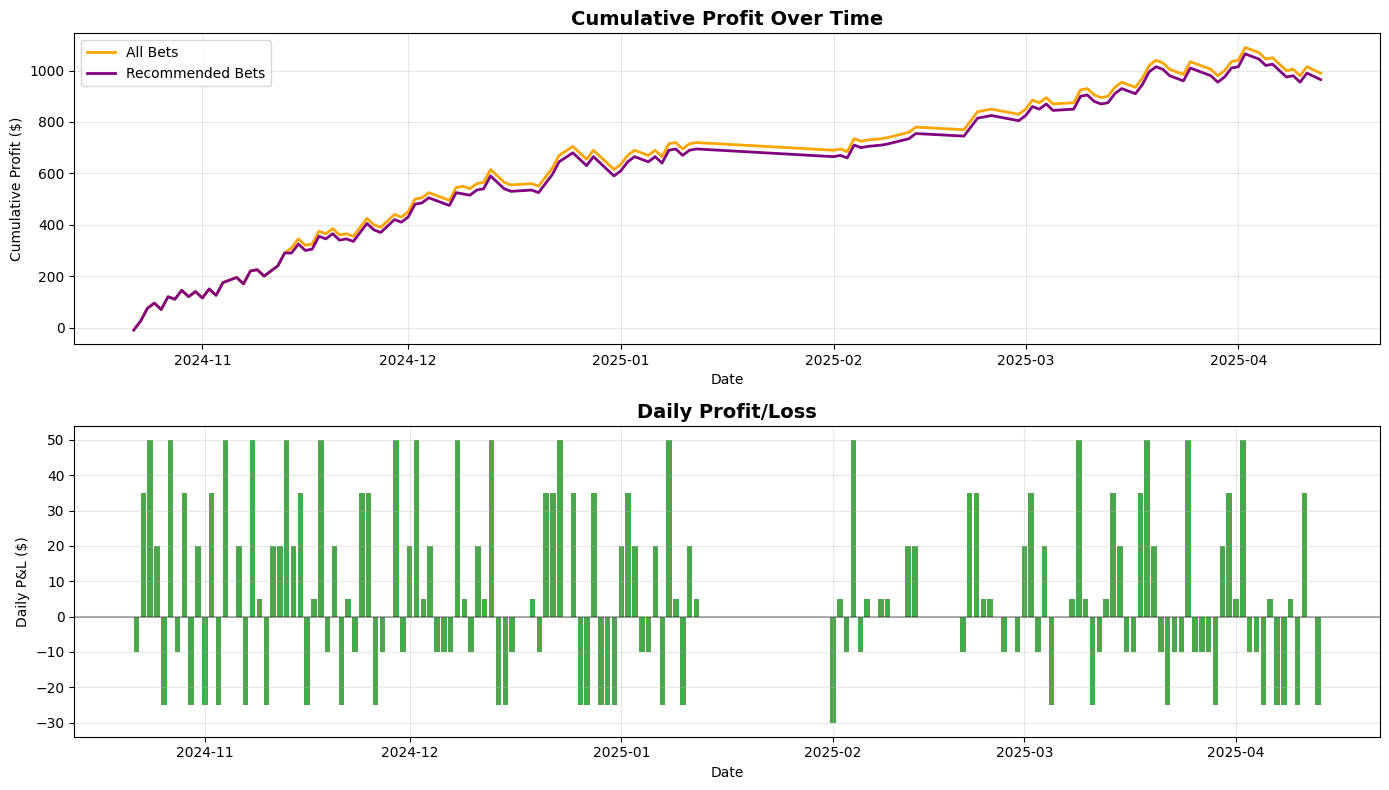

In [8]:
all_metrics = calculatePairMetrics(final_results, stake=5)

# Calculate metrics for recommended bets only
recommended = final_results[final_results['pair_recommendation'] == 1]
rec_metrics = calculatePairMetrics(recommended, stake=5)

# Display comprehensive results
print("=" * 60)
print("           COMPREHENSIVE BETTING ANALYSIS")
print("=" * 60)

if all_metrics:
    print(f"\n ALL BETS ANALYSIS:")
    print(f"   Total Bets: {all_metrics['total_bets']:,}")
    print(f"   Wins: {all_metrics['total_wins']:,}")
    print(f"   Hit Rate: {all_metrics['win_rate']:.2%}")
    print(f"   Total Profit: ${all_metrics['total_profit']:,.2f}")
    print(f"   Total Staked: ${all_metrics['total_staked']:,.2f}")
    print(f"   ROI: {all_metrics['roi_percent']:.2f}%")
    print(f"   Volatility: ${all_metrics['volatility']:.2f}")
    print(f"   Max Drawdown: ${all_metrics['max_drawdown']:.2f}")
    print(f"   Sharpe Ratio: {all_metrics['sharpe_ratio']:.3f}")
    
    # Display probability metrics
    if 'probability_metrics' in all_metrics and 'error' not in all_metrics['probability_metrics']:
        prob_metrics = all_metrics['probability_metrics']
        print(f"\n   PROBABILITY METRICS:")
        print(f"   Brier Score: {prob_metrics.get('brier_score', 'N/A'):.4f} (lower is better)")
        print(f"   Log Loss: {prob_metrics.get('log_loss', 'N/A'):.4f} (lower is better)")
        if not np.isnan(prob_metrics.get('auc_roc', np.nan)):
            print(f"   AUC-ROC: {prob_metrics.get('auc_roc', 'N/A'):.4f} (higher is better)")
        else:
            print(f"   AUC-ROC: NaN ({prob_metrics.get('auc_roc_note', 'Only one class present')})")
        print(f"   Samples: {prob_metrics.get('n_samples', 'N/A')}")

if rec_metrics:
    print("\n RECOMMENDED BETS ANALYSIS (Edge > 0.20):")
    print(f"   Total Bets: {rec_metrics['total_bets']:,}")
    print(f"   Wins: {rec_metrics['total_wins']:,}")
    print(f"   Hit Rate: {rec_metrics['win_rate']:.2%}")
    print(f"   Total Profit: ${rec_metrics['total_profit']:,.2f}")
    print(f"   Total Staked: ${rec_metrics['total_staked']:,.2f}")
    print(f"   ROI: {rec_metrics['roi_percent']:.2f}%")
    print(f"   Volatility: ${rec_metrics['volatility']:.2f}")
    print(f"   Max Drawdown: ${rec_metrics['max_drawdown']:.2f}")
    print(f"   Sharpe Ratio: {rec_metrics['sharpe_ratio']:.3f}")
    
    # # Display probability metrics for recommended bets
    if 'probability_metrics' in rec_metrics and 'error' not in rec_metrics['probability_metrics']:
        prob_metrics = rec_metrics['probability_metrics']
        print(f"\n   PROBABILITY METRICS:")
        print(f"   Brier Score: {prob_metrics.get('brier_score', 'N/A'):.4f} (lower is better)")
        print(f"   Log Loss: {prob_metrics.get('log_loss', 'N/A'):.4f} (lower is better)")
        if not np.isnan(prob_metrics.get('auc_roc', np.nan)):
            print(f"   AUC-ROC: {prob_metrics.get('auc_roc', 'N/A'):.4f} (higher is better)")
        else:
            print(f"   AUC-ROC: NaN ({prob_metrics.get('auc_roc_note', 'Only one class present')})")
        print(f"   Samples: {prob_metrics.get('n_samples', 'N/A')}")

# Plots cumulative profit over time
if all_metrics and not all_metrics['daily_pnl'].empty:
    plt.figure(figsize=(14, 8))
    
    plt.subplot(2, 1, 1)
    plt.plot(all_metrics['daily_pnl']['date'], all_metrics['daily_pnl']['cumulative_profit'], 
             linewidth=2, label='All Bets', color='orange')
    if rec_metrics and not rec_metrics['daily_pnl'].empty:
        plt.plot(rec_metrics['daily_pnl']['date'], rec_metrics['daily_pnl']['cumulative_profit'], 
                 linewidth=2, label='Recommended Bets', color='purple')
    plt.title('Cumulative Profit Over Time', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Profit ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 1, 2)
    plt.bar(all_metrics['daily_pnl']['date'], all_metrics['daily_pnl']['profit'], 
            alpha=0.7, label='Daily P&L', color='green')
    plt.title('Daily Profit/Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Daily P&L ($)')
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()